In [2]:

import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.signal import butter, lfilter
from scipy.signal import find_peaks
from scipy.signal import savgol_filter, peak_prominences
from scipy.interpolate import interp1d

# Data Loading

In [185]:
# Load Head Data
file_path_head = r'C:\Users\Lindsay\Documents\alexander\Deer_project\deer_code\R4_D1_LH.csv'
columns_to_keep_head = ['TagID', 'Date', 'Time', 'X', 'Y', 'Z', 'location-lat','location-lon']
head_data_in= pd.read_csv(file_path_head,usecols=columns_to_keep_head)
head_data=head_data_in.copy()
#head_data[['location-lat', 'location-lon']]=head_data[['location-lat', 'location-lon']].ffill() # removing the nas by filling gps loection known last
#head_data[['location-lat', 'location-lon']]=head_data[['location-lat', 'location-lon']].bfill()
head_data['DateTime_Global'] = pd.to_datetime(head_data['Date'] + ' ' + head_data['Time'],format=r"%d/%m/%Y %H:%M:%S.%f")
head_data['NZ_DateTime'] = head_data['DateTime_Global'] + pd.Timedelta(hours=13)
head_data.drop(['Date', 'Time'], axis=1, inplace=True)


# Load Ear Data
file_path_ear = r'C:\Users\Lindsay\Documents\alexander\Deer_project\deer_code\R4_D1_LE.csv'
columns_to_keep_ear = ['TagID', 'Date', 'Time', 'X', 'Y', 'Z']
ear_data_in= pd.read_csv(file_path_ear, usecols=columns_to_keep_ear)
ear_data=ear_data_in.copy()
ear_data['DateTime_Global'] = pd.to_datetime(ear_data['Date'] + ' ' + ear_data['Time'],format=r"%d/%m/%Y %H:%M:%S.%f")
ear_data['NZ_DateTime'] = ear_data['DateTime_Global'] + pd.Timedelta(hours=13)
ear_data.drop(['Date', 'Time'], axis=1, inplace=True)

head_data_in=head_data.copy()
ear_data_in=ear_data.copy()

In [186]:
head_data=head_data_in.copy()
ear_data=ear_data_in.copy()

# Functions

In [193]:


def correct_calibration(data, cols=['X', 'Y', 'Z']): # does nothing at the meoment could add later
    cols_to_calibrate = data[cols]
    
    # for column in cols_to_calibrate:
    #     cols_to_calibrate[column] =cols_to_calibrate[column]- calibration_row[column][0]
    return cols_to_calibrate

def make_absolute(data):
    """
    Make each column in a Pandas DataFrame the absolute value of itself.

    Parameters:
    - data (pd.DataFrame): The input DataFrame.

    Returns:
    - pd.DataFrame: The DataFrame with absolute values for each column.
    """

    # Create a copy of the DataFrame to avoid modifying the original data
    absolute_data = data.copy()

    # Take the absolute value of each column
    absolute_data = abs(absolute_data)
    return absolute_data


def sum_columns(data, columns_to_sum=['X', 'Y', 'Z']):
    """
    Sum together specified columns in a Pandas DataFrame.

    Parameters:
    - data (pd.DataFrame): The input DataFrame.
    - columns_to_sum (list): List of column names to sum together.

    Returns:
    - pd.Series: A Series representing the sum of the specified columns.
    """

    # Sum together specified columns
    result_series = data[columns_to_sum].sum(axis=1)

    return result_series



def get_calibrated_absolute_accelleration(data):
    """
    Calculate the total absolute acceleration for each row in a DataFrame.

    Parameters:
    - data (pd.DataFrame): The input DataFrame containing acceleration data.

    Returns:
    - pd.Series: A Series representing the total absolute acceleration for each row.
    """
    normalised_cols = correct_calibration(data)
    absolute_cols = make_absolute(normalised_cols)
    summed_cols = sum_columns(absolute_cols)
    return summed_cols



def get_consecutive_differences(points): # gets difference between one point and its next t2 and returns this smal distance matriux as pd data frame
    distances = []
    for i in range(len(points)):
        if i < len(points) - 2:
            dist_to_next_1 = points[i+1] - points[i]
            dist_to_next_2 = points[i+2] - points[i]
            distances.append([points[i], dist_to_next_1, dist_to_next_2])
        #else:
            #distances.append([points[i], None, None]) # f not 2 more exist it doesnt do anything

    # Create a DataFrame from the distances list
    df = pd.DataFrame(distances, columns=['Point', 'Distance_to_next_1', 'Distance_to_next_2'])

    return(df)



def find_3_drops(peaks_ear, peaks_head,margin_of_error = 10,drop_window_seconds = 10): # finds ,matching 3 distances from a point in 2 signals and retursn the index of the first for each signal, or None if it cant find any
    drop_window_ticks = drop_window_seconds*50
    peaks_ear = get_consecutive_differences(peaks_ear)
    peaks_head = get_consecutive_differences(peaks_head)
    # Merge the two DataFrames on the condition that the absolute difference between the distances is within the margin of error

    matched_points = []

    for _, row1 in peaks_ear.iterrows(): # add to data frame if 3 drops are matching within margin of error the distances, and all occurr within a window defined
        for _, row2 in peaks_head.iterrows():
            if (abs(row1['Distance_to_next_1'] - row2['Distance_to_next_1']) <= margin_of_error and
                    abs(row1['Distance_to_next_2'] - row2['Distance_to_next_2']) <= margin_of_error) and  abs(row1['Distance_to_next_2'] )<=drop_window_ticks:
                matched_points.append((row1['Point'], row2['Point']))

    if(len(matched_points)==0):
        print("no drops found")
        return {}
    if(len(matched_points)>=2):
        print("Warning, FOund Multiple Sets of Matching Consecutive Drops, Run again with Plot=true to check manually")
    print("Number_of_matched_points= ",len(matched_points))
    # Convert matched_points to DataFrame
    resulting_points = pd.DataFrame(matched_points, columns=['first_drop_index_ear', 'first_drop_index_head'])
    drops_dict={"point_ear" : resulting_points.iloc[0,0],"point_head" : resulting_points.iloc[0,1]}
    return(drops_dict)

def plot_drops(ear_data,head_data,point_ear,point_head,start):
    time_period=""
    if(start==True):
        time_period = "Start"
    else:
        time_period="End"
        
    plt.plot(head_data["NZ_DateTime"], head_data["absolute_accelleration"], label='Head Data')

    # Plot NZ_DateTime against absolute_accelleration for ear data
    plt.plot(ear_data["NZ_DateTime"], ear_data["absolute_accelleration"], label='Ear Data')

    # Highlight the points in red
    plt.plot(head_data["NZ_DateTime"].iloc[point_head], head_data["absolute_accelleration"].iloc[point_head], 'ro')
    plt.plot(ear_data["NZ_DateTime"].iloc[point_ear], ear_data["absolute_accelleration"].iloc[point_ear], 'ro')

    # Add labels and legend
    plt.xlabel('NZ_DateTime')
    plt.ylabel('absolute_accelleration')

    plt.title(str(time_period)+' calibration period total Absolute Accelleration Vs Time of Ear And Head data')
    plt.legend()
    plt.figure(figsize=(30, 20)) 
    # Show the plot
    plt.show()
    
def find_calibration_points(ear_data_window_in, head_data_window_in, prominence_level=2, plot=True, start=True):
    ear_data_window=ear_data_window_in.copy()
    head_data_window=head_data_window_in.copy()
    
    ear_data_window["absolute_accelleration"]=get_calibrated_absolute_accelleration(ear_data_window)
    head_data_window["absolute_accelleration"]=get_calibrated_absolute_accelleration(head_data_window)
    
    drops = {}

    peaks_ear,_ = find_peaks(ear_data_window["absolute_accelleration"], prominence=prominence_level)
    peaks_head,_ = find_peaks(head_data_window["absolute_accelleration"], prominence=prominence_level)
    drops = find_3_drops(peaks_ear,peaks_head)

    if plot==True and (not drops)!=True :
        point_ear=drops["point_ear"]
        point_head = drops["point_head"]
        plot_drops(ear_data_window,head_data_window,point_ear,point_head,start=start)
    return(drops)

def find_signal_match(head_data, ear_data, window_dict, max_window_increase_factor=4,initial_prominence_level=2,prominence_limit=1,prominence_decrement = 0.25, make_plot=True):
    # LOOPS THROUGH PROMINENCE AND WINDOW SIZES
    # make the windows here, then cuse it to step and print what it does as well as graphing. step one window at a time by 10 0000 this means signals can be out by up to 600 seconds'"AT1 Rep 1 S1Blue 12-13.11_S1.csv"
    end_window_beginning_index_head = window_dict['end_window_beginning_index_head']
    end_window_end_index_head = window_dict['end_window_end_index_head']
    
    end_window_beginning_index_ear = window_dict['end_window_beginning_index_ear']
    end_window_end_index_ear = window_dict['end_window_end_index_ear']
    
    start_window_beginning_index_head = window_dict['start_window_beginning_index_head']
    start_window_end_index_head = window_dict['start_window_end_index_head']
    
    start_window_beginning_index_ear = window_dict['start_window_beginning_index_ear']
    start_window_end_index_ear = window_dict['start_window_end_index_ear']
    # GENERATE INITIAL DATA WINDOWS
    data_window_head_end=head_data[end_window_beginning_index_head:end_window_end_index_head].reset_index()
    data_window_ear_end=ear_data[end_window_beginning_index_ear:end_window_end_index_ear].reset_index()
    
    data_window_head_start=head_data[start_window_beginning_index_head:start_window_end_index_head].reset_index()
    data_window_ear_start=ear_data[start_window_beginning_index_ear:start_window_end_index_ear].reset_index()
    
    
    # dEFINE HERE WHAT THE LOOP RETURNS
    prominence_level = initial_prominence_level  # Change this to your desired number
    drops_start = {} 
    
    # loop should go through increasing the window up to a defined limit of increase  numbers then if it doesnt find dropss, then decrements prominmence limit and does the same
    # until both limits reached if still not found
    while(not drops_start):
        loop_counter=0
        while(not drops_start): # keeps running while drops is not created
            if(loop_counter>max_window_increase_factor):
                break
            drops_start= find_calibration_points(data_window_ear_start, data_window_head_start, prominence_level=prominence_level, plot=make_plot,start=True)
            if not drops_start:
                data_window_head_start=head_data[start_window_beginning_index_head:(start_window_end_index_head*2)].reset_index()
                data_window_ear_start=ear_data[start_window_beginning_index_ear:(start_window_end_index_ear*2)].reset_index()
                print("window Size Doubled")
                loop_counter+=1
        if(not drops_start):
            prominence_level=prominence_level-prominence_decrement
            print("DECREMENTING PROMINENCE TO ",prominence_level )
        if(prominence_level<prominence_limit):
            break
        
    if not drops_start: # igf loop broke and did not make drops this means that there is a problem with finding start drops and returns empty df
        print("ERROR,COULD NOT FIND START CALIBRATION DROP WITHIN ,",max_window_increase_factor,"X WINDOW SIZE")
        return({})
    
    
    
    prominence_level = initial_prominence_level  # Change this to your desired number
    drops_end = {} 
    
    # loop should go through increasing the window up to a defined limit of increase  numbers then if it doesnt find dropss, then decrements prominmence limit and does the same
    # until both limits reached if still not found
    while(not drops_end):
        loop_counter=0
        while(not drops_end): # keeps running while drops is not created
            if(loop_counter>max_window_increase_factor):
                break
            drops_end= find_calibration_points(data_window_ear_end, data_window_head_end, prominence_level=prominence_level, plot=make_plot,start=False)
            if not drops_end:
                data_window_head_end=head_data[end_window_beginning_index_head:(end_window_end_index_head*2)].reset_index()
                data_window_ear_end=ear_data[end_window_beginning_index_ear:(end_window_end_index_ear*2)].reset_index()
                print("window Size Doubled")
                loop_counter+=1
        if(not drops_end):
            prominence_level=prominence_level-prominence_decrement
            print("DECREMENTING PROMINENCE TO ",prominence_level )
        if(prominence_level<prominence_limit):
            break
        
    if not drops_end: # igf loop broke and did not make drops this means that there is a problem with finding end drops and returns empty df
        print("ERROR,COULD NOT FIND end CALIBRATION DROP WITHIN ,",max_window_increase_factor,"X WINDOW SIZE")
        return({})
    
    # Return drops to original frame of reference
    drops_end["point_ear"]=drops_end["point_ear"]+end_window_beginning_index_ear
    drops_end["point_head"]=drops_end["point_head"]+end_window_beginning_index_head
    drops_start["point_ear"]=drops_start["point_ear"]+start_window_beginning_index_ear
    drops_start["point_head"]=drops_start["point_head"]+start_window_beginning_index_head
    
    return({"drops_start":drops_start,"drops_end":drops_end})






0

In [188]:
head_data=head_data_in.copy()
ear_data=ear_data_in.copy()
window_dict = {
    'end_window_beginning_index_head': head_data.shape[0] - 20000,
    'end_window_end_index_head': head_data.shape[0],
    'end_window_beginning_index_ear': ear_data.shape[0] - 20000,
    'end_window_end_index_ear': ear_data.shape[0],
    'start_window_beginning_index_head': 0,
    'start_window_end_index_head': 20000,
    'start_window_beginning_index_ear': 0,
    'start_window_end_index_ear': 20000
}


no drops found
window Size Doubled
Number_of_matched_points=  1


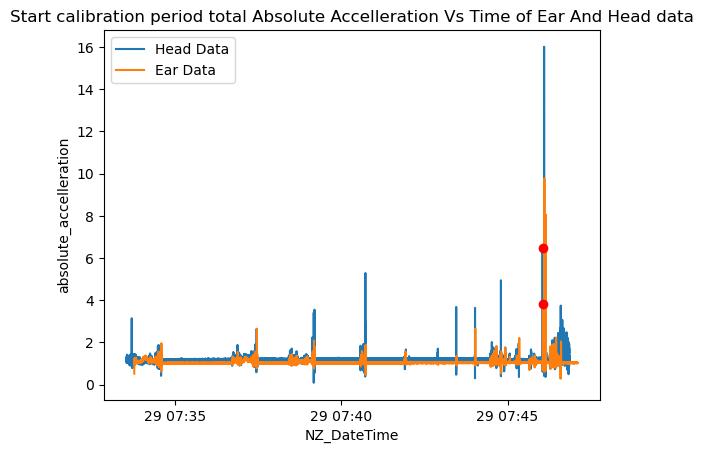

<Figure size 3000x2000 with 0 Axes>

no drops found
window Size Doubled
no drops found
window Size Doubled
no drops found
window Size Doubled
no drops found
window Size Doubled
no drops found
window Size Doubled
DECREMENTING PROMINENCE TO  1.75
Number_of_matched_points=  1


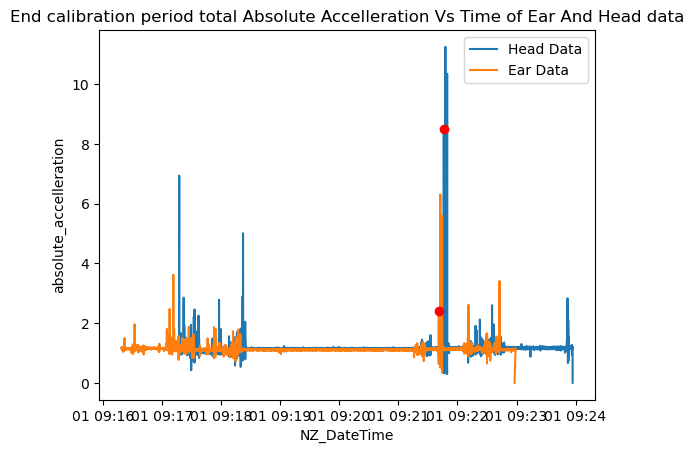

<Figure size 3000x2000 with 0 Axes>

In [194]:
drop_dict=find_signal_match(head_data, ear_data, window_dict) # must fail on this

In [195]:
drop_dict
start_drop_ear = drop_dict["drops_start"]["point_ear"]
start_drop_head = drop_dict["drops_start"]["point_head"]
end_drop_ear = drop_dict["drops_end"]["point_ear"]
end_drop_head = drop_dict["drops_end"]["point_head"]



ear_data_cut = ear_data.iloc[start_drop_ear:end_drop_ear,:].reset_index(drop=True)
head_data_cut = head_data.iloc[start_drop_head:end_drop_head,:].reset_index(drop=True)

head_n_rows=head_data_cut.shape[0]
ear_n_rows =ear_data_cut.shape[0]

cols = ['X', 'Y', 'Z']
interpolated_ear_data = pd.DataFrame([])
for c in cols:
    interpolated_ear_data[c] = np.interp(
        np.linspace(0, ear_n_rows - 1, head_n_rows),
        range(ear_n_rows),
        ear_data_cut[c]
    )

interpolated_ear_data.reset_index(drop=True, inplace=True)
interpolated_ear_data.columns = [f"{col}_ear" for col in interpolated_ear_data.columns]
accell_data= pd.concat([head_data_cut, interpolated_ear_data], axis=1)
new_column_names_for_head = {'X': 'X_head', 'Y': 'Y_head', 'Z': 'Z_head'}
accell_data = accell_data.rename(columns=new_column_names_for_head)

# Generate Absolute Columns and Prominent Peaks

In [196]:
cols = ['X', 'Y', 'Z']
interpolated_ear_data = pd.DataFrame([])
for c in cols:
    interpolated_ear_data[c] = np.interp(
        np.linspace(0, ear_n_rows - 1, head_n_rows),
        range(ear_n_rows),
        ear_data_cut[c]
    )


In [197]:
interpolated_ear_data

,X,Y,Z
0,-0.127800,0.288700,-3.416600
1,-0.045603,0.445595,-0.713784
2,-0.318783,0.207815,0.592118
3,-0.183113,-0.013079,0.498109
4,-0.151604,-0.038797,0.534395
...,...,...,...
8927143,-0.036905,-0.027497,0.764384
8927144,-0.079401,-0.005005,0.633092
8927145,-0.093796,-0.062509,0.546890
8927146,-0.031194,-0.203153,0.390578


In [ ]:
interpolated_ear_data.reset_index(drop=True, inplace=True)

In [95]:
interpolated_ear_data.columns = [f"{col}_ear" for col in interpolated_ear_data.columns]
accell_data= pd.concat([head_data_cut, interpolated_ear_data], axis=1)

<Axes: >

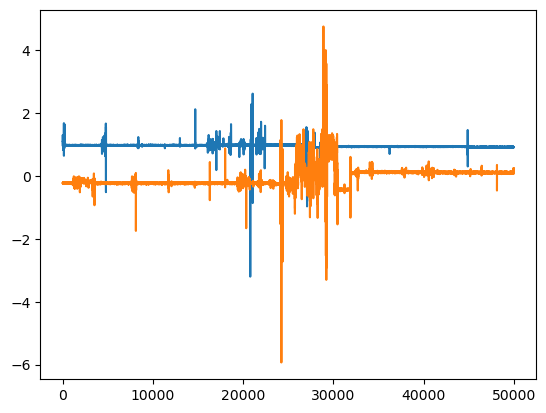

In [96]:
accell_data.head(50000).Z_ear.plot()
accell_data.head(50000).Z.plot()

In [13]:
new_column_names_for_head = {'X': 'X_head', 'Y': 'Y_head', 'Z': 'Z_head'}
all_accell = all_accell.rename(columns=new_column_names_for_head)

In [14]:
all_accell

,TagID,X_head,Y_head,Z_head,location-lat,location-lon,DateTime_Global,NZ_DateTime,X_ear,Y_ear,Z_ear
0,AT1 rep4 29-30.11_S1,0.0328,0.9359,-0.2203,NaN,NaN,2018-11-28 18:38:01.100,2018-11-29 07:38:01.100,-0.047500,0.077500,1.124700
1,AT1 rep4 29-30.11_S1,0.0312,0.9512,-0.2325,NaN,NaN,2018-11-28 18:38:01.120,2018-11-29 07:38:01.120,-0.001918,0.198051,1.244952
2,AT1 rep4 29-30.11_S1,0.0447,0.9397,-0.2209,NaN,NaN,2018-11-28 18:38:01.140,2018-11-29 07:38:01.140,-0.000002,0.261849,1.308749
3,AT1 rep4 29-30.11_S1,0.0469,0.9375,-0.2319,NaN,NaN,2018-11-28 18:38:01.160,2018-11-29 07:38:01.160,-0.028765,0.222548,1.269448
4,AT1 rep4 29-30.11_S1,0.0341,0.9247,-0.2344,NaN,NaN,2018-11-28 18:38:01.180,2018-11-29 07:38:01.180,-0.031196,0.148519,1.181342
...,...,...,...,...,...,...,...,...,...,...,...
8951246,AT1 rep4 29-30.11_S1,-0.0944,0.7978,-0.0003,NaN,NaN,2018-11-30 20:21:46.020,2018-12-01 09:21:46.020,-0.036968,-0.027464,0.764189
8951247,AT1 rep4 29-30.11_S1,-0.0338,0.7669,-0.0300,NaN,NaN,2018-11-30 20:21:46.040,2018-12-01 09:21:46.040,-0.079417,-0.005069,0.632996
8951248,AT1 rep4 29-30.11_S1,-0.0019,0.6334,-0.0900,NaN,NaN,2018-11-30 20:21:46.060,2018-12-01 09:21:46.060,-0.093750,-0.062613,0.546774
8951249,AT1 rep4 29-30.11_S1,-0.0575,0.1219,-0.1369,NaN,NaN,2018-11-30 20:21:46.080,2018-12-01 09:21:46.080,-0.031120,-0.203777,0.390317


In [199]:
all_accell.to_hdf('R4D1_Combined.h5', key='df', mode='w')

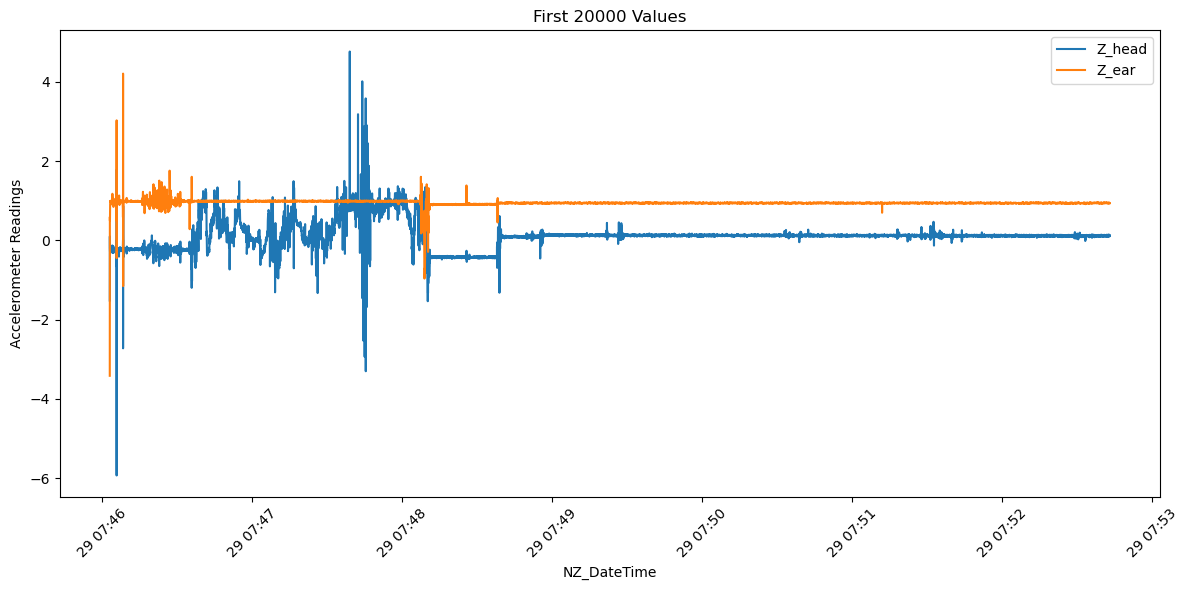

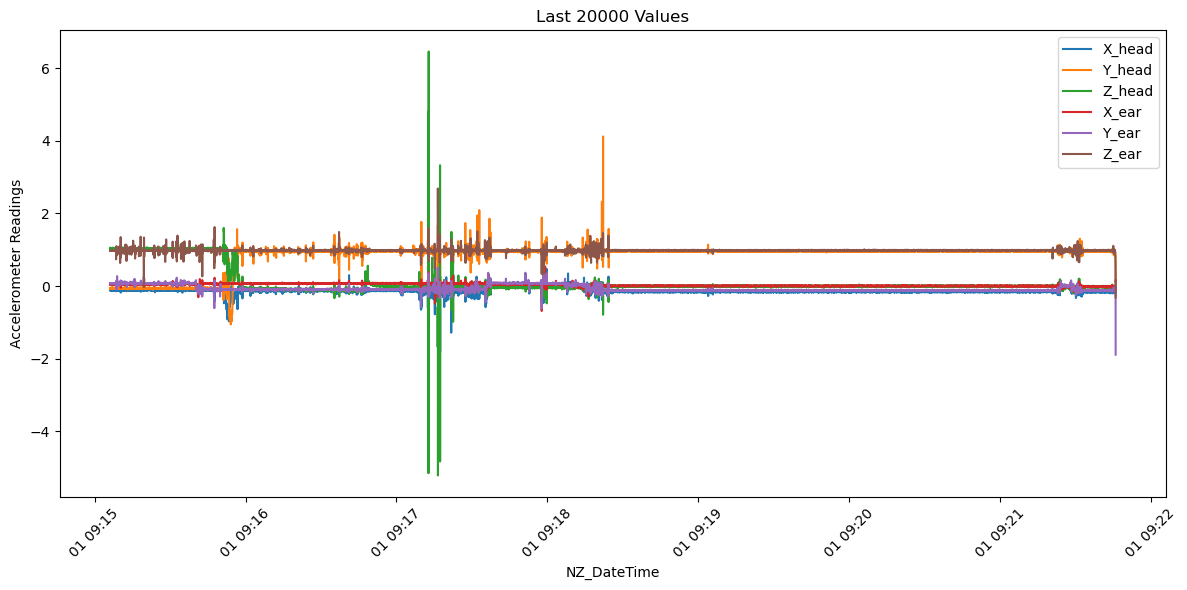

In [198]:
all_accell=accell_data
# Assuming all_accell is your DataFrame

# Plotting the first 20000 values
plt.figure(figsize=(12, 6))
# plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['X_head'].iloc[:20000], label='X_head')
# plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['Y_head'].iloc[:20000], label='Y_head')
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['Z_head'].iloc[:20000], label='Z_head')
# plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['X_ear'].iloc[:20000], label='X_ear')
# plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['Y_ear'].iloc[:20000], label='Y_ear')
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['Z_ear'].iloc[:20000], label='Z_ear')
plt.xlabel('NZ_DateTime')
plt.ylabel('Accelerometer Readings')
plt.title('First 20000 Values')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plotting the last 20000 values
plt.figure(figsize=(12, 6))
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['X_head'].iloc[-20000:], label='X_head')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['Y_head'].iloc[-20000:], label='Y_head')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['Z_head'].iloc[-20000:], label='Z_head')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['X_ear'].iloc[-20000:], label='X_ear')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['Y_ear'].iloc[-20000:], label='Y_ear')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['Z_ear'].iloc[-20000:], label='Z_ear')
plt.xlabel('NZ_DateTime')
plt.ylabel('Accelerometer Readings')
plt.title('Last 20000 Values')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




# Calculate Lag at which start and end SIgnals are most correlated

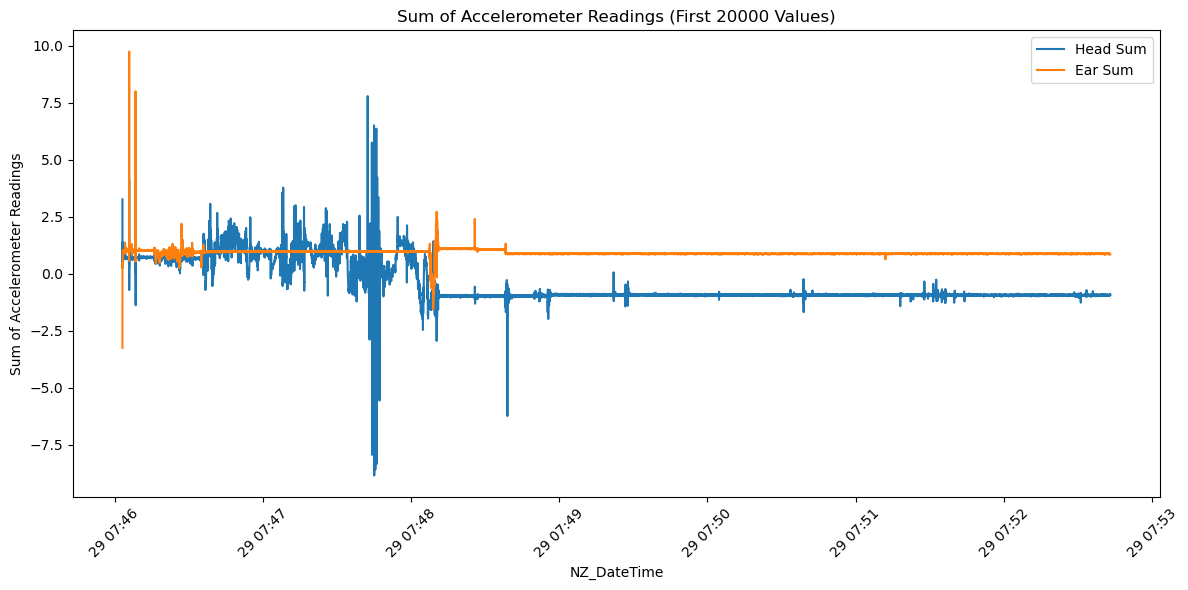

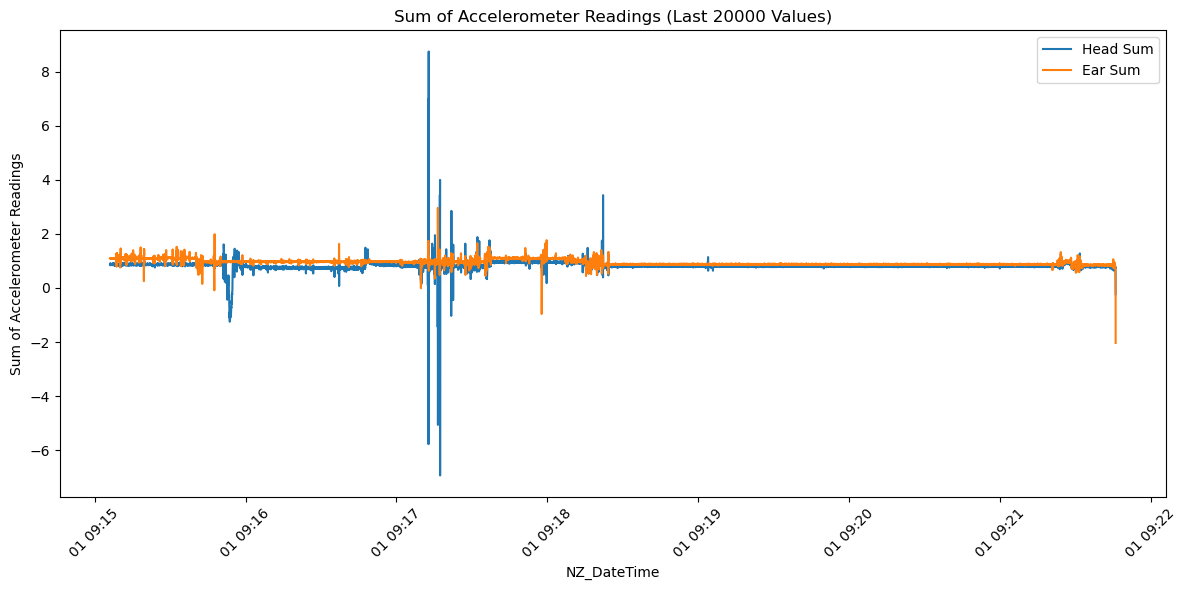

In [200]:
# Calculate the sum of accelerometer data for the first 20000 values
sum_head_first_20000 = all_accell[['X_head', 'Y_head', 'Z_head']].iloc[:20000].sum(axis=1)
sum_ear_first_20000 = all_accell[['X_ear', 'Y_ear', 'Z_ear']].iloc[:20000].sum(axis=1)

# Plotting the sum of accelerometer data for the first 20000 values
plt.figure(figsize=(12, 6))
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], sum_head_first_20000, label='Head Sum')
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], sum_ear_first_20000, label='Ear Sum')
plt.xlabel('NZ_DateTime')
plt.ylabel('Sum of Accelerometer Readings')
plt.title('Sum of Accelerometer Readings (First 20000 Values)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate the sum of accelerometer data for the last 20000 values
sum_head_last_20000 = all_accell[['X_head', 'Y_head', 'Z_head']].iloc[-20000:].sum(axis=1)
sum_ear_last_20000 = all_accell[['X_ear', 'Y_ear', 'Z_ear']].iloc[-20000:].sum(axis=1)

# Plotting the sum of accelerometer data for the last 20000 values
plt.figure(figsize=(12, 6))
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], sum_head_last_20000, label='Head Sum')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], sum_ear_last_20000, label='Ear Sum')
plt.xlabel('NZ_DateTime')
plt.ylabel('Sum of Accelerometer Readings')
plt.title('Sum of Accelerometer Readings (Last 20000 Values)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


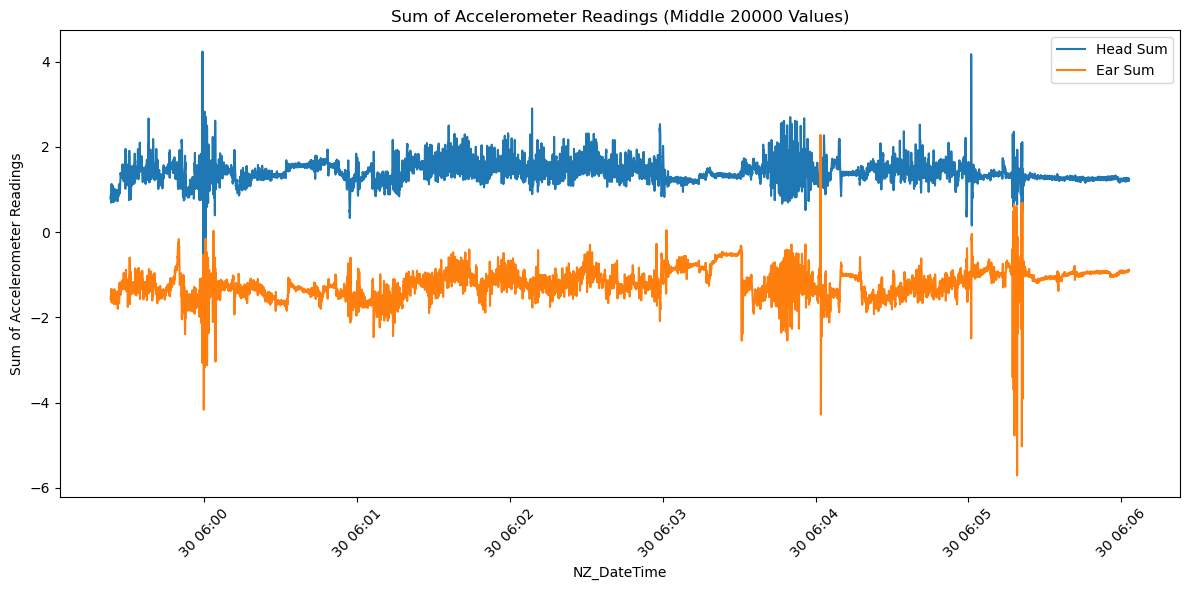

In [202]:
# Calculate the sum of accelerometer data for the first 20000 values
sum_head_middle_20000 = all_accell[['X_head', 'Y_head', 'Z_head']].iloc[4000000:4020000].sum(axis=1)
sum_ear_middle_20000 = all_accell[['X_ear', 'Y_ear', 'Z_ear']].iloc[4000000:4020000].sum(axis=1)

# Plotting the sum of accelerometer data for the first 20000 values
plt.figure(figsize=(12, 6))
plt.plot(all_accell['NZ_DateTime'].iloc[4000000:4020000], sum_head_middle_20000, label='Head Sum')
plt.plot(all_accell['NZ_DateTime'].iloc[4000000:4020000], sum_ear_middle_20000, label='Ear Sum')
plt.xlabel('NZ_DateTime')
plt.ylabel('Sum of Accelerometer Readings')
plt.title('Sum of Accelerometer Readings (Middle 20000 Values)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



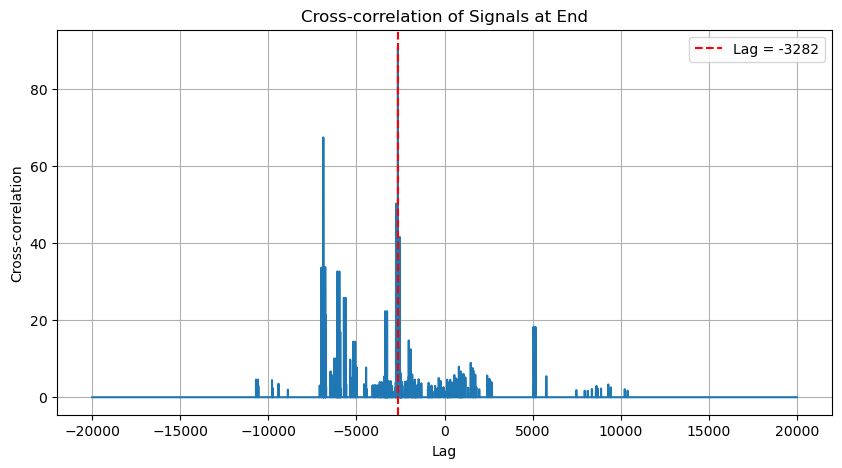

Maximum correlation: 90.77301132000002
Lag (in samples): -3282
Signals are likely similar with a phase shift.


In [ ]:

# Assuming your signals are stored in pandas DataFrames df1 and df2
signal1 = data_window_head_end['prom'].values
signal2 = data_window_ear_end['prom'].values
threshold=10
# Compute cross-correlation
cross_corr = np.correlate(signal1, signal2, mode='full')

# Find the lag corresponding to the maximum correlation
lag_start = np.argmax(cross_corr) - len(signal1) + 1

# Plot cross-correlation
plt.figure(figsize=(10, 5))
plt.plot(np.arange(-len(signal1) + 1, len(signal2)), cross_corr)
plt.axvline(lag_start, color='r', linestyle='--', label=f'Lag = {lag}')
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation of Signals at End')
plt.legend()
plt.grid(True)
plt.show()

# Check if the maximum correlation is close to 1
max_corr = np.max(cross_corr)
if max_corr > threshold:
    print("Maximum correlation:", max_corr)
    print("Lag (in samples):", lag)
    print("Signals are likely similar with a phase shift.")
else:
    print("Signals are not similar.")

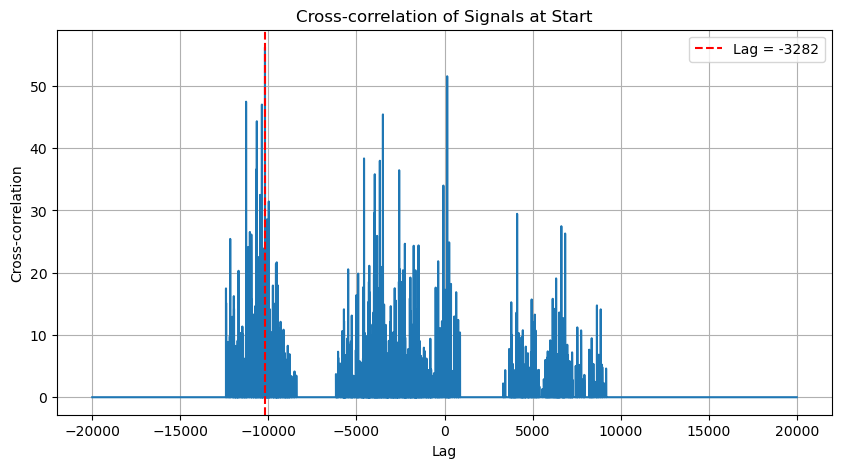

Maximum correlation: 56.201960699999994
Lag (in samples): -3282
Signals are likely similar with a phase shift.


In [ ]:

# Assuming your signals are stored in pandas DataFrames df1 and df2
signal1 = data_window_head_start['prom'].values
signal2 = data_window_ear_start['prom'].values
threshold=10
# Compute cross-correlation
cross_corr = np.correlate(signal1, signal2, mode='full')

# Find the lag corresponding to the maximum correlation
lag_end = np.argmax(cross_corr) - len(signal1) + 1

# Plot cross-correlation
plt.figure(figsize=(10, 5))
plt.plot(np.arange(-len(signal1) + 1, len(signal2)), cross_corr)
plt.axvline(lag_end, color='r', linestyle='--', label=f'Lag = {lag}')
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation of Signals at Start')
plt.legend()
plt.grid(True)
plt.show()

# Check if the maximum correlation is close to 1
max_corr = np.max(cross_corr)
if max_corr > threshold:
    print("Maximum correlation:", max_corr)
    print("Lag (in samples):", lag)
    print("Signals are likely similar with a phase shift.")
else:
    print("Signals are not similar.")

# Aligning Signals

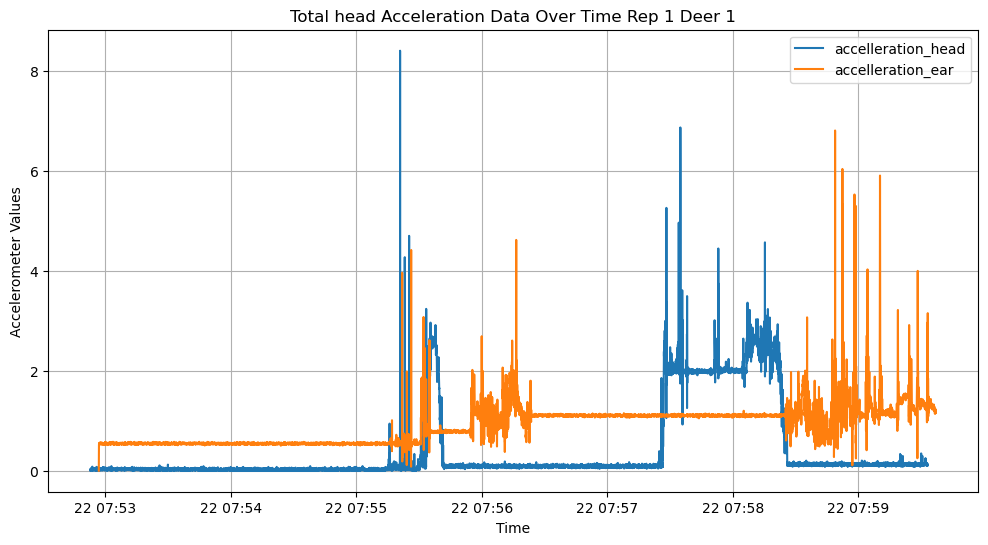

In [ ]:
# Downsample the data to a manageable size, for example, every 1000th data point
df = data_window_head_start
df1= data_window_ear_start
# Set up the plot
plt.figure(figsize=(12, 6))

# Plot X, Y, and Z over time
plt.plot(df['NZ_DateTime'], df['absolute_accelleration'], label='accelleration_head')
plt.plot(df1['NZ_DateTime'], df1['absolute_accelleration'], label='accelleration_ear')
# Customize the plot
plt.title('Total head Acceleration Data Over Time Rep 1 Deer 1')
plt.xlabel('Time')
plt.ylabel('Accelerometer Values')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
import pandas as pd

def find_matching_peak_sets(peaks1, peaks2, max_spacing=(7*50)):
    matching_sets = []

    for i in range(len(peaks1) - 2):
        for j in range(len(peaks2) - 2):
            spacing1 = peaks1[i+1] - peaks1[i]
            spacing2 = peaks2[j+1] - peaks2[j]
            if np.abs(spacing1 - spacing2) <= max_spacing:
                if peaks1[i+2] - peaks1[i+1] == spacing1 and peaks2[j+2] - peaks2[j+1] == spacing2:
                    matching_sets.append((peaks1[i], peaks1[i+1], peaks1[i+2], peaks2[j], peaks2[j+1], peaks2[j+2]))
    
    return matching_sets

find_matching_peak_sets(peaks_ear_end, peaks_head_end)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\IPython\core\interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Lindsay\AppData\Local\Temp\ipykernel_20836\1530273085.py", line 16, in <module>
    find_matching_peak_sets(peaks_ear_end, peaks_head_end)
  File "C:\Users\Lindsay\AppData\Local\Temp\ipykernel_20836\1530273085.py", line None, in find_matching_peak_sets
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\IPython\core\interactiveshell.py", line 2144, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\IPython\core\ultratb.py", line 1435, in structured_traceback
    return Form

In [ ]:
len(peaks_ear_end)
len(peaks_head_end)
len(peaks_ear_start)
len(peaks_head_start)

27